# ex2data1 数据分析

使用 Scikit-learn 对 `ex2data1.txt` 进行二分类分析。

**数据说明**：这是经典的逻辑回归入门数据集，共 3 列：
- 第 1 列：第一次考试成绩（Exam1）
- 第 2 列：第二次考试成绩（Exam2）
- 第 3 列：是否被录取（1 = 录取，0 = 未录取）

**任务**：根据两次考试成绩预测学生是否会被录取。

## 1. 导入所需库并读取数据

In [1]:
# 数据处理
import numpy as np
import pandas as pd

# 展示输出
from IPython.display import display

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

# 模型与评估
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# 读取数据（无表头，指定列名）
df = pd.read_csv('ex2data1.txt', header=None,
                 names=['exam1', 'exam2', 'admitted'])

print('数据形状:', df.shape)
display(df.head())


数据形状: (100, 3)


,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


## 2. 数据探索

In [2]:
# 2.1 基本信息统计
display(df.describe())

,exam1,exam2,admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [3]:
# 2.2 检查缺失值
print('缺失值统计：')
display(df.isnull().sum())

缺失值统计：


exam1       0
exam2       0
admitted    0
dtype: int64

In [4]:
# 2.3 类别分布（是否平衡）
print('录取情况分布：')
display(df['admitted'].value_counts())

录取情况分布：


admitted
1    60
0    40
Name: count, dtype: int64

### 2.4 数据可视化


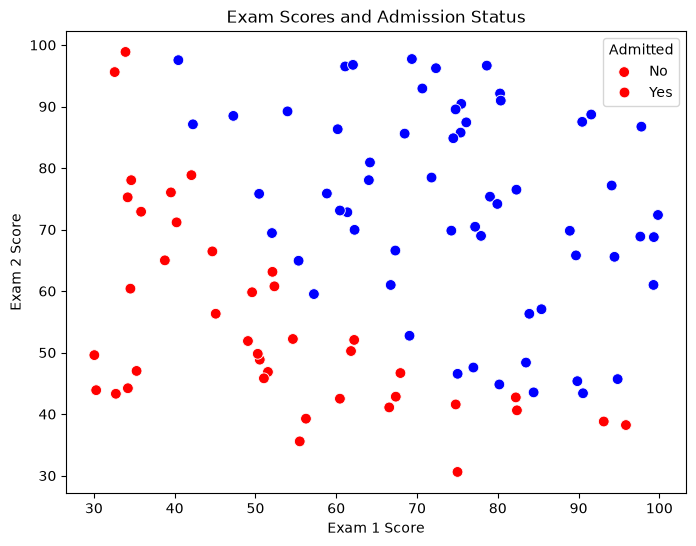

In [22]:
# 2.4.1 Scatter plot: exam scores vs admission status
plt.figure(figsize=(8, 6))

# 按录取与否分别绘制散点
sns.scatterplot(data=df, x='exam1', y='exam2',
                hue='admitted', palette={0: 'red', 1: 'blue'}, s=60)

plt.title('Exam Scores and Admission Status')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(title='Admitted', labels=['No', 'Yes'])
plt.show()


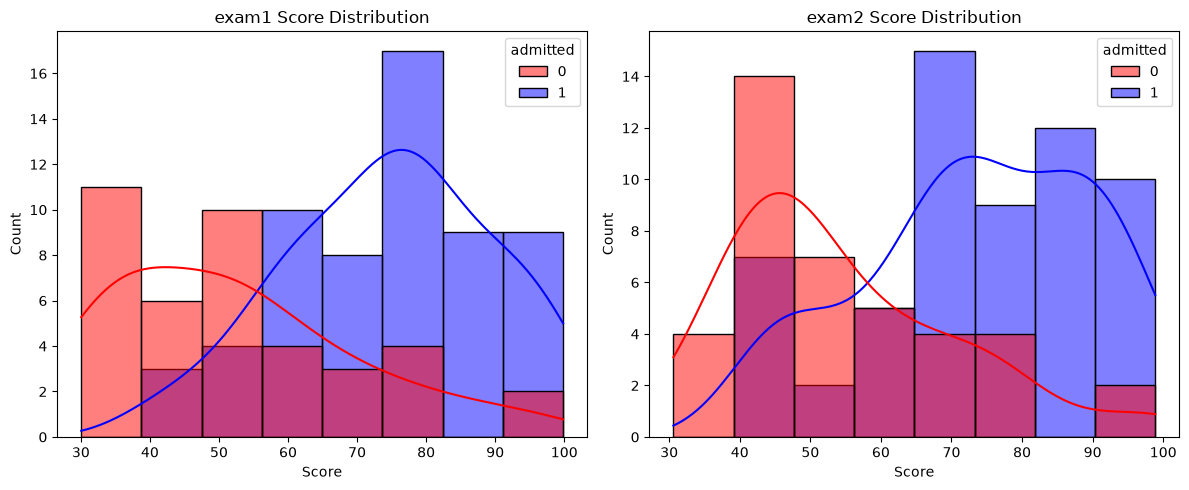

In [6]:
# 2.4.2 Histograms of exam scores (grouped by admission status)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['exam1', 'exam2']):
    sns.histplot(data=df, x=col, hue='admitted',
                 kde=True, palette={0: 'red', 1: 'blue'}, ax=ax)
    ax.set_title(f'{col} Score Distribution')
    ax.set_xlabel('Score')

plt.tight_layout()
plt.show()


## 3. 构建逻辑回归模型

In [7]:
# 3.1 分离特征和标签
X = df[['exam1', 'exam2']]   # 特征：两次考试成绩
y = df['admitted']           # 标签：是否录取

# 3.2 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

print(f'训练集样本数: {len(X_train)}')
print(f'测试集样本数: {len(X_test)}')

训练集样本数: 70
测试集样本数: 30


In [8]:
# 3.3 创建并训练逻辑回归模型
clf = LogisticRegression()
clf.fit(X_train, y_train)

print('模型训练完成！')
display(pd.DataFrame({
    '特征': ['Exam1', 'Exam2', '截距'],
    '系数': [clf.coef_[0][0], clf.coef_[0][1], clf.intercept_[0]]
}))

模型训练完成！


,特征,系数
0,Exam1,0.184950
1,Exam2,0.186424
2,截距,-23.277198


In [9]:
# 3.4 在测试集上预测并评估
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# 显式计算精确率、召回率、F1（以"录取"为正类，即 pos_label=1）
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f'准确率 (Accuracy): {acc:.4f}')
print(f'精确率 (Precision): {precision:.4f}')
print(f'召回率 (Recall): {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

print('\n混淆矩阵：')
display(pd.DataFrame(confusion_matrix(y_test, y_pred),
                     index=['实际未录取', '实际录取'],
                     columns=['预测未录取', '预测录取']))

# 用表格汇总各评估指标
display(pd.DataFrame({
    '评估指标': ['准确率 Accuracy', '精确率 Precision', '召回率 Recall', 'F1 Score'],
    '含义': ['预测正确的比例',
            '被预测为录取的样本中真正录取的比例',
            '实际录取的样本中被正确预测的比例',
            '精确率与召回率的调和平均'],
    '数值': [acc, precision, recall, f1]
}))


准确率 (Accuracy): 0.8667
精确率 (Precision): 1.0000
召回率 (Recall): 0.7895
F1 Score: 0.8824

混淆矩阵：


,预测未录取,预测录取
实际未录取,11,0
实际录取,4,15


,评估指标,含义,数值
0,准确率 Accuracy,预测正确的比例,0.866667
1,精确率 Precision,被预测为录取的样本中真正录取的比例,1.000000
2,召回率 Recall,实际录取的样本中被正确预测的比例,0.789474
3,F1 Score,精确率与召回率的调和平均,0.882353


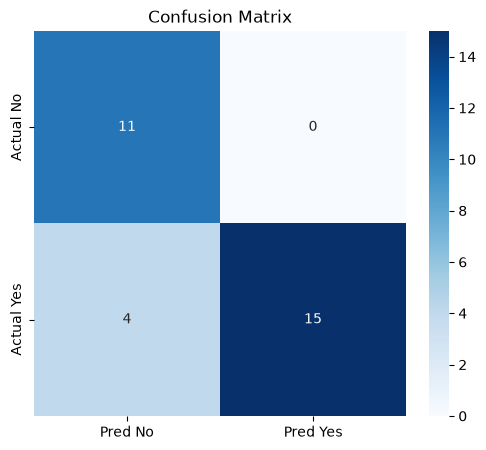

In [10]:
# 3.5 Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.show()


In [11]:
# 3.6 详细的分类报告（精确率、召回率、F1）
print('分类报告：')
print(classification_report(y_test, y_pred, target_names=['未录取', '录取']))


分类报告：
              precision    recall  f1-score   support

         未录取       0.73      1.00      0.85        11
          录取       1.00      0.79      0.88        19

    accuracy                           0.87        30
   macro avg       0.87      0.89      0.86        30
weighted avg       0.90      0.87      0.87        30



## 4. 用模型进行预测示例

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


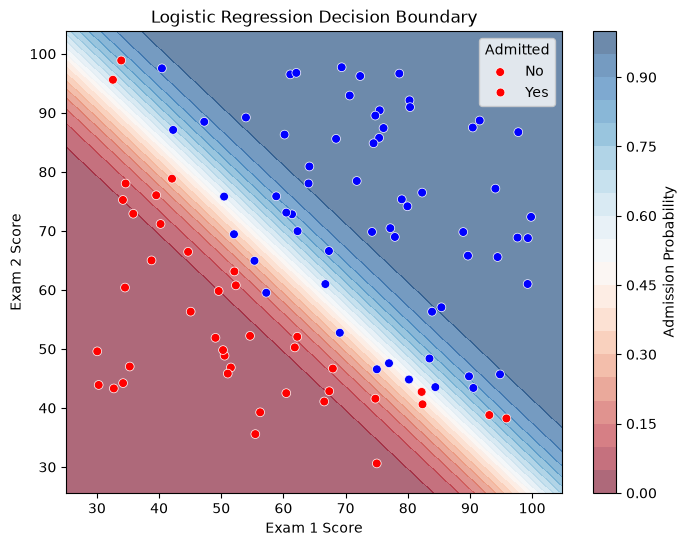

In [12]:
# 4.1 Decision boundary visualization
plt.figure(figsize=(8, 6))

# 生成网格点，计算每个点的预测概率
x1_min, x1_max = df['exam1'].min() - 5, df['exam1'].max() + 5
x2_min, x2_max = df['exam2'].min() - 5, df['exam2'].max() + 5
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                     np.linspace(x2_min, x2_max, 300))

# 用模型预测整个网格的录取概率
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# 绘制概率等值线背景
contour = plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(contour, label='Admission Probability')

# 叠加原始数据散点
sns.scatterplot(data=df, x='exam1', y='exam2',
                hue='admitted', palette={0: 'red', 1: 'blue'}, s=40)

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend(title='Admitted', labels=['No', 'Yes'])
plt.show()


In [13]:
# 4.2 预测新学生的录取概率
new_students = pd.DataFrame({
    'exam1': [45, 85, 70],
    'exam2': [85, 95, 60]
})

prob = clf.predict_proba(new_students)[:, 1]   # 录取的概率
pred = clf.predict(new_students)

result = new_students.copy()
result['录取概率'] = prob.round(4)
result['预测结果'] = ['录取' if p == 1 else '未录取' for p in pred]
display(result)


,exam1,exam2,录取概率,预测结果
0,45,85,0.7092,录取
1,85,95,1.0000,录取
2,70,60,0.7016,录取


## 5. 学习曲线：判断是否过拟合

**学习曲线**展示：随着训练样本数量增加，模型在**训练集**和**交叉验证集**上的得分变化。

- **过拟合**：训练集得分远高于验证集得分，且两者差距大（两条曲线明显分开）
- **欠拟合**：两条曲线都偏低（模型太简单）
- **拟合良好**：两条曲线随样本增加逐渐靠拢，验证集得分高且稳定


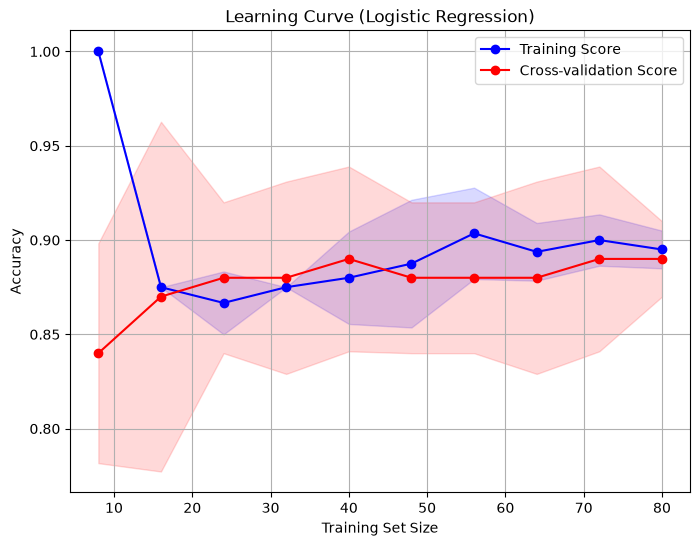

In [14]:
# 5.1 绘制学习曲线
from sklearn.model_selection import learning_curve

# 计算学习曲线：训练集大小从 10% 逐步增加到 100%
train_sizes, train_scores, valid_scores = learning_curve(
    LogisticRegression(), X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', random_state=0)

# 计算均值和标准差（用于绘制置信区间带）
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

plt.figure(figsize=(8, 6))

# 训练集得分曲线
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='blue')

# 交叉验证得分曲线
plt.plot(train_sizes, valid_mean, 'o-', color='red', label='Cross-validation Score')
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std,
                 alpha=0.15, color='red')

plt.title('Learning Curve (Logistic Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()


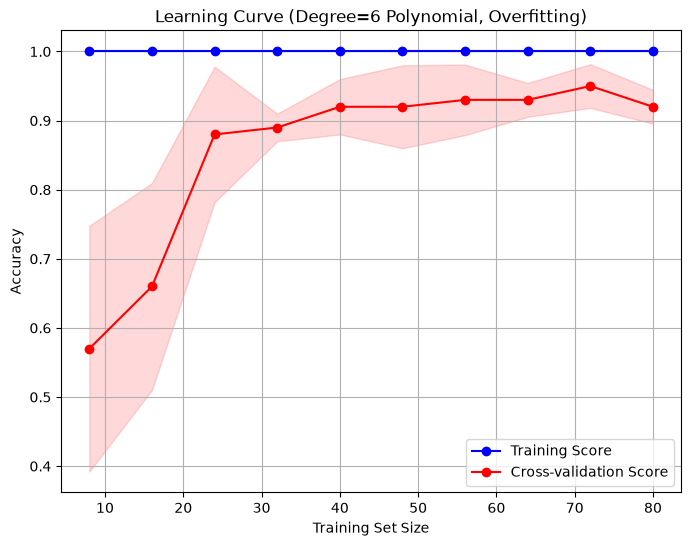

In [15]:
# 5.2 对比：使用高次多项式特征（容易过拟合）的学习曲线
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 构建 degree=6 的管道模型（特征升维后更容易过拟合）
poly_clf = make_pipeline(PolynomialFeatures(degree=6), LogisticRegression(max_iter=1000))

train_sizes2, train_scores2, valid_scores2 = learning_curve(
    poly_clf, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', random_state=0)

train_mean2 = train_scores2.mean(axis=1)
train_std2 = train_scores2.std(axis=1)
valid_mean2 = valid_scores2.mean(axis=1)
valid_std2 = valid_scores2.std(axis=1)

plt.figure(figsize=(8, 6))

plt.plot(train_sizes2, train_mean2, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes2, train_mean2 - train_std2, train_mean2 + train_std2,
                 alpha=0.15, color='blue')
plt.plot(train_sizes2, valid_mean2, 'o-', color='red', label='Cross-validation Score')
plt.fill_between(train_sizes2, valid_mean2 - valid_std2, valid_mean2 + valid_std2,
                 alpha=0.15, color='red')

plt.title('Learning Curve (Degree=6 Polynomial, Overfitting)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()
